# Interpolation
This notebook runs a linear interpolation of SLA data in the month of Jan 2020.

In [16]:
import pandas as pd
import numpy as np
import os
import time

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_path = "/home/mhen/.local/share/fonts/IBMPlexSerif-Regular.ttf"
font_prop = fm.FontProperties(fname=font_path)

plt.rcParams["font.family"] = font_prop.get_name()
plt.rcParams["font.sans-serif"] = [font_prop.get_name()]

from GPSat.utils import WGS84toEASE2
from GPSat.local_experts import LocalExpertOI, get_results_from_h5file
from GPSat.postprocessing import smooth_hyperparameters, glue_local_predictions_1d

In [4]:
data_df = pd.read_csv('/home/mhen/geol0069_data/jan20.csv')

In [5]:
#keep data from january

data_df = data_df.loc[data_df['date_string'].str.contains('2020-01', na=False)]

In [6]:
data_df.head()

,x,y,lon,lat,t,z,track,date_string,satellite,lead_mask,dist_along_track,z_track_avg
2573650,-585146.902831,-432100.026835,-53.556094,83.483790,18262.0,NaN,1243,2020-01-01,cs2,0.0,0.000000,0.040157
2573651,-584280.987782,-430861.767792,-53.594113,83.496633,18262.0,-0.034818,1243,2020-01-01,cs2,1.0,1502.990248,0.040157
2573652,-584107.820675,-430614.140368,-53.601734,83.499201,18262.0,-0.018846,1243,2020-01-01,cs2,1.0,1803.558120,0.040157
2573653,-583934.553028,-430366.439101,-53.609361,83.501770,18262.0,NaN,1243,2020-01-01,cs2,0.0,2104.243152,0.040157
2573654,-583588.157115,-429871.156267,-53.624632,83.506906,18262.0,NaN,1243,2020-01-01,cs2,0.0,2705.434872,0.040157


In [7]:
test_track = data_df.loc[data_df['track'] == 1257]
test_track.head()

,x,y,lon,lat,t,z,track,date_string,satellite,lead_mask,dist_along_track,z_track_avg
2601689,-638579.271484,2.242111e+06,-164.10243,69.001559,18262.0,-0.746479,1257,2020-01-01,cs2,1.0,0.000000,-0.026275
2601690,-638462.214874,2.241838e+06,-164.10336,69.004244,18262.0,-0.798415,1257,2020-01-01,cs2,1.0,300.176217,-0.026275
2601691,-638111.488080,2.241019e+06,-164.10614,69.012299,18262.0,-0.665761,1257,2020-01-01,cs2,1.0,1200.652652,-0.026275
2601692,-637409.906412,2.239382e+06,-164.11171,69.028408,18262.0,-0.714593,1257,2020-01-01,cs2,1.0,3001.529271,-0.026275
2601693,-637292.936222,2.239109e+06,-164.11264,69.031093,18262.0,-0.669882,1257,2020-01-01,cs2,1.0,3301.699913,-0.026275


In [93]:
def random_holdout_test(data_df, holdout_fraction=0.2, seed=42, gpsat_experts=128):
    rng = np.random.default_rng(seed)

    #separate into tracks and iterate over each
    tracks = data_df['track'].unique()
    
    results_df = pd.DataFrame()
    results_metrics_df = pd.DataFrame()
    plot_data_df = pd.DataFrame()
    for i, track in enumerate(tracks):
        print(f'Interpolating track {track}, {i+1} of {len(tracks)}...')
        track_df = data_df.loc[data_df['track']==track]
        #locate leads
        leads_df = track_df.loc[track_df['lead_mask']==1.0]
        #create test (holdout) indices of length 1 or of holdout fraction, whichever is larger
        n_test = max(1, int(len(leads_df) * holdout_fraction))

        #exclude tracks with insufficient leads
        if len(leads_df) < 5:
            print(f"Insufficient leads ({len(leads_df)}) for random holdout, skipping...")
            continue

        #find lead indices and randomly select 80% for training
        leads_idx = leads_df.index
        test_lead_idx = rng.choice(leads_df.index, size=n_test, replace=False)
        train_lead_idx = np.array(leads_df.index.difference(test_lead_idx))
        track_df['train_mask'] = track_df.index.isin(train_lead_idx)


        # Compute distances before interpolation - nearest distance to a train lead of each test lead
        lead_D = leads_df.loc[leads_idx, 'dist_along_track'].to_numpy()
        train_D = leads_df.loc[train_lead_idx, 'dist_along_track'].to_numpy()
        test_D = leads_df.loc[test_lead_idx, 'dist_along_track'].to_numpy()
        if train_D.size > 0 and test_D.size > 0:
            nearest_dists_km = np.min(np.abs(test_D[:, None] - train_D[None, :]), axis=1) / 1000.0
        else:
            nearest_dists_km = np.array([])

        #run linear and gpsat interpolation
        start = time.perf_counter()
        result_track_lin = linear_interpolation(track_df, train_lead_idx)
        end = time.perf_counter()
        lin_time = end - start
        result_track_gpsat, gpsat_time = gpsat_interpolation(track_df, train_lead_idx, max_experts = gpsat_experts)
        result_track = result_track_lin.join(result_track_gpsat[['f_gpsat_SMOOTHED','f_var_gpsat_SMOOTHED']])

        #find test values - withheld leads
        linear_preds = result_track.loc[test_lead_idx,'f_lin'].to_numpy()
        gpsat_preds = result_track.loc[test_lead_idx, 'f_gpsat_SMOOTHED'].to_numpy()
        gpsat_var = result_track.loc[test_lead_idx,'f_var_gpsat_SMOOTHED'].to_numpy()
        targets = result_track.loc[test_lead_idx, 'z'].to_numpy()
        dist_along_track = result_track.loc[test_lead_idx, 'dist_along_track'].to_numpy()

        print(f"Test NaNs — Linear: {np.sum(~np.isfinite(linear_preds))}, GPSat: {np.sum(~np.isfinite(gpsat_preds))}")
        both_valid = (np.isfinite(linear_preds) & np.isfinite(gpsat_preds) & np.isfinite(targets))
        if np.sum(both_valid) == 0:
            print(f"FAILED: No valid predictions from both methods on random holdout")
            continue

        #find metrics for the prediction
        lin_res = linear_preds[both_valid] - targets[both_valid]
        gp_res = gpsat_preds[both_valid] - targets[both_valid]

        def _r2(a, b):
            return np.corrcoef(a, b)[0,1]**2 if len(a) > 1 else np.nan
        
        # Calculate GPSat uncertainty at test leads for calibration check
        if gpsat_var is not None:
            gpsat_std = np.sqrt(gpsat_var[both_valid])
            avg_gpsat_uncertainty = float(np.mean(gpsat_std))
        else:
            avg_gpsat_uncertainty = None
        
        # Distance and lead spacing stats
        dist_mean = float(np.nanmean(nearest_dists_km)) if nearest_dists_km.size else np.nan
        dist_median = float(np.nanmedian(nearest_dists_km)) if nearest_dists_km.size else np.nan
        dist_max = float(np.nanmax(nearest_dists_km)) if nearest_dists_km.size else np.nan
        dist_min = float(np.nanmin(nearest_dists_km)) if nearest_dists_km.size else np.nan
        spacing_km = np.diff(lead_D) / 1000.0 if lead_D.size > 1 else np.array([])
        sp_med = float(np.nanmedian(spacing_km)) if spacing_km.size else np.nan
        sp_p90 = float(np.nanpercentile(spacing_km, 90)) if spacing_km.size else np.nan
        sp_max = float(np.nanmax(spacing_km)) if spacing_km.size else np.nan

        #add metrics to dataframe
        metrics_dict = {
            'track' : track,
            'n_predictions': int(np.sum(both_valid)),
            'n_train': int(len(train_lead_idx)),
            'n_test': int(len(test_lead_idx)),
            'nearest_train_km': {
                'mean': dist_mean, 'median': dist_median, 'max': dist_max, 'min': dist_min
            },
            'lead_spacing_km': {
                'median': sp_med, 'p90': sp_p90, 'max': sp_max
            },
            'linear': {
                'rmse': float(np.sqrt(np.mean(lin_res**2))),
                'bias': float(np.mean(lin_res)),
                'mae': float(np.mean(np.abs(lin_res))),
                'r2': float(_r2(linear_preds[both_valid], targets[both_valid])),
                'interp_time' : lin_time
            },
            'gpsat_along': {
                'rmse': float(np.sqrt(np.mean(gp_res**2))),
                'bias': float(np.mean(gp_res)),
                'mae': float(np.mean(np.abs(gp_res))),
                'r2': float(_r2(gpsat_preds[both_valid], targets[both_valid])),
                'avg_uncertainty': avg_gpsat_uncertainty,
                'interp_time' : gpsat_time
                },
        }
        plot_data_dict = {
            'track' : track,
            'linear_preds': linear_preds[both_valid].copy(),
            'gpsat_preds': gpsat_preds[both_valid].copy(),
            'gpsat_var' : gpsat_var[both_valid].copy(),
            'targets': targets[both_valid].copy(),
            'nearest_dists_km': nearest_dists_km[both_valid] if nearest_dists_km.size > 0 else np.array([]),
            'linear_residuals': lin_res.copy(),
            'gpsat_residuals': gp_res.copy(),
            'dist_along_track': dist_along_track[both_valid].copy()
        }


        track_plot_data_df = pd.DataFrame(plot_data_dict)
        plot_data_df = pd.concat([plot_data_df, track_plot_data_df])

        results_df = pd.concat([results_df, result_track])
        track_metrics_df = pd.json_normalize([metrics_dict])
        results_metrics_df = pd.concat([results_metrics_df, track_metrics_df])

        print(f'Track interpolated!')
    print('All tracks interpolated')

    return plot_data_df, results_df, results_metrics_df


def linear_interpolation(track_df, train_lead_idx, filter_width_km=100):
    obs_df = track_df['z']
    train_leads_df = track_df.loc[train_lead_idx]

    # Filter leads by height
    height_valid = (train_leads_df['z']>= -0.5) & (train_leads_df['z'] <= 0.5)
    train_leads_df = train_leads_df.loc[height_valid]

    #terminate if too short for linear interpolation
    if len(train_leads_df) < 2:
        print('Too few leads for linear interpolation, returning NaN')
        obs_df['f_lin'] = np.nan
        track_df = pd.merge(track_df, obs_df['f_lin'], left_index=True, right_index=True)
        
        return track_df
    
    # apply 100 km box filter to smooth lead observations
    smoothed_obs_df = obs_df.copy()

    # For each lead point, smooth with nearby leads within filter_width_km
    for idx, lead in train_leads_df.iterrows():
        lead_distances = np.abs(train_leads_df['dist_along_track'] - train_leads_df['dist_along_track'].loc[idx])
        within_window = lead_distances <= (filter_width_km * 1000 / 2)  # ±50 km    
        if np.sum(within_window) > 0:
            smoothed_obs_df.loc[idx] = (train_leads_df['z'][within_window]).mean()

    # linear interpolation between smoothed lead values - covers all obs points
    obs_df = obs_df.to_frame()
    obs_df['f_lin'] = np.nan
        
    for i0, i1 in zip(train_leads_df.index[:-1], train_leads_df.index[1:]):
        v0, v1 = smoothed_obs_df.loc[i0], smoothed_obs_df.loc[i1]
        span = i1 - i0
        if span <= 0:
            obs_df['f_lin'].loc[i0] = v0
            continue
        ii = np.arange(i0, i1 + 1)
        obs_df['f_lin'].loc[ii] = v0 + (v1 - v0) * (ii - i0) / span

    # flat extrapolation beyond the first/last training lead
    first_idx, last_idx = train_leads_df.index[0], train_leads_df.index[-1]
    obs_df.loc[:first_idx, 'f_lin'] = smoothed_obs_df.loc[first_idx]
    obs_df.loc[last_idx:, 'f_lin'] = smoothed_obs_df.loc[last_idx]

    track_df = pd.merge(track_df, obs_df['f_lin'], left_index=True, right_index=True)

    return track_df

def gpsat_interpolation(track_df, train_lead_idx, max_experts=128):
    
    obs_df = track_df['z']
    train_leads_df = track_df.loc[train_lead_idx]

    # Filter leads by height
    height_valid = (train_leads_df['z']>= -0.5) & (train_leads_df['z'] <= 0.5)
    train_leads_df = train_leads_df.loc[height_valid]

    #if too short, terminate and return NaN
    if len(train_leads_df)<3:
        print('Too few leads for GPSat interpolation, returning NaN')
        track_df['f_gpsat'] = np.nan
        
        return track_df
    
    #select experts
    experts_df = select_experts(train_leads_df, max_experts = max_experts)

    if len(experts_df) < 2:
        print('Too few experts for GPSat, returning NaN')
        track_df['f_gpsat'] = np.nan
        
        return track_df
    
    #run gpsat interpolation
    track = track_df['track'].iloc[0]

    store_path = f'/home/mhen/geol0069_data/gpsat/jan20/{track}.h5'

    if os.path.exists(store_path):
        os.remove(store_path)
    
    ssha, ssha_var, ssha_SMOOTHED, ssha_var_SMOOTHED, run_time = run_gpsat(track_df, train_leads_df, experts_df, store_path)

    track_df['f_gpsat'] = ssha
    track_df['f_var_gpsat'] = ssha_var
    track_df['f_gpsat_SMOOTHED'] = ssha_SMOOTHED
    track_df['f_var_gpsat_SMOOTHED'] = ssha_var_SMOOTHED

    return track_df, run_time

def select_experts(leads_df, spacing=25e3, max_experts=128):
    try:
        dist_along_track = leads_df['dist_along_track']
    except KeyError as ke:
        print(f'{ke}: Make sure distance along track is calculated')
        return
    
    grid = np.arange(0, dist_along_track.iloc[-1], spacing)
    selected = []
    used = set()

    for target in grid:
        if len(selected) >= max_experts:
            print('Expert limit reached.')
            break
        #subtract each target dist from the dist of each lead, and so find
        #the closest lead to target from the smallest value
        idx = (dist_along_track-target).abs().idxmin()
        #select lead and add to selected and used
        if idx not in used:
            selected.append(idx)
            used.add(idx)
    
    if len(selected) < 3:
        #if we have too few experts
        #find the unselected leads
        remaining_idx = leads_df.index.difference(selected)
        #find no. experts to add
        n_to_add = max_experts-len(remaining_idx)
        #add indices evenly spaced from remaining unselected indices
        step = max(1, len(remaining_idx) // n_to_add)
        idx_added = remaining_idx[::step][:n_to_add]

        selected.extend(list(idx_added))

    experts_df = leads_df.loc[selected]

    return experts_df

def run_gpsat(track_df, leads_df, experts_df, store_path):

    # Notebook-style config: 3D coords, 400km, 100-200km lengthscales
    coords_col = ["x", "y", "t"]
    local_select = [
        {"col": ["x", "y"], "comp": "<=", "val": 400_000},
        {"col": "t", "comp": "<=", "val": 1.0},
        {"col": "t", "comp": ">=", "val": -1.0}
    ]
    data_config = {
        "data_source": leads_df,
        "obs_col": "z",
        "coords_col": coords_col,
        "local_select": local_select,
        "global_select": [{"col": "lat", "comp": ">=", "val": 45}]
    }
    expert_config = {"source" : experts_df}
    pred_config = {"method": "from_dataframe", "df": track_df,
                   "max_dist" : 400_000}
    # Notebook-style: 100-200km lengthscales for 3D
    length_low = [100_000, 100_000, 1e-08]
    length_high = [200_000, 200_000, 4]
    coords_scale = [10_000, 10_000, 1]

    model_config = {
    "oi_model": "GPflowGPRModel",
    "init_params": {"coords_scale": coords_scale, "minibatch_size": 100},
    "constraints": {
        "lengthscales": {"low": length_low, "high": length_high},
        "likelihood_variance": {"low": 0.001, "high": 10}  # Lower noise floor for better endpoint adherence
        }
    }
    # Full mode: enable smoothing (3D coords have x/y)
    locexp = LocalExpertOI(expert_config, data_config, model_config, pred_config)
    locexp.run(store_path=store_path, optimise=True)
    dfs, _ = get_results_from_h5file(store_path)
    run_details = dfs['run_details']
    smooth_hyperparameters(
        result_file=store_path,
        params_to_smooth=["lengthscales", "kernel_variance", "likelihood_variance"],
        smooth_config_dict={
            "lengthscales": dict(l_x=200_000, l_y=200_000, max=12),
            "likelihood_variance": dict(l_x=200_000, l_y=200_000),
            "kernel_variance": dict(l_x=200_000, l_y=200_000, max=0.1)
        },
        save_config_file=False
    )
    model_config['load_params'] = {"file": store_path, "table_suffix": "_SMOOTHED"}
    locexp = LocalExpertOI(expert_config, data_config, model_config, pred_config)
    locexp.run(store_path=store_path, optimise=False, predict=True, table_suffix='_SMOOTHED')

    # Extract results
    dfs, _ = get_results_from_h5file(store_path)
    preds = dfs["preds"]

    # Glue
    preds['xprt_locs'] = np.sqrt((preds['x'] - preds['x'].iloc[0])**2 + (preds['y'] - preds['y'].iloc[0])**2)
    preds['pred_locs'] = np.sqrt((preds['pred_loc_x'] - preds['pred_loc_x'].iloc[0])**2 + 
                                    (preds['pred_loc_y'] - preds['pred_loc_y'].iloc[0])**2)
    glue_max = 400_000  # Full mode uses 400km like notebook

    glued = glue_local_predictions_1d(preds, "pred_locs", "xprt_locs", ["f*", "f*_var"], glue_max)
    ssha = glued['f*'].values
    ssha_var = glued['f*_var'].values if 'f*_var' in glued.columns else None

    preds_SMOOTHED = dfs["preds_SMOOTHED"]

    #measure interpolation time
    run_time = run_details['run_time']
    run_time_SMOOTHED = run_details_SMOOTHED['run_time']

    total_time = run_time.cumsum()
    total_time_SMOOTHED = run_time_SMOOTHED.cumsum()

    final_total_time = total_time.iloc[-1] + total_time_SMOOTHED.iloc[-1]

    # Glue
    preds_SMOOTHED['xprt_locs'] = np.sqrt((preds_SMOOTHED['x'] - preds_SMOOTHED['x'].iloc[0])**2 + (preds_SMOOTHED['y'] - preds_SMOOTHED['y'].iloc[0])**2)
    preds_SMOOTHED['pred_locs'] = np.sqrt((preds_SMOOTHED['pred_loc_x'] - preds_SMOOTHED['pred_loc_x'].iloc[0])**2 + 
                                    (preds_SMOOTHED['pred_loc_y'] - preds_SMOOTHED['pred_loc_y'].iloc[0])**2)
    
    glued_SMOOTHED = glue_local_predictions_1d(preds_SMOOTHED, "pred_locs", "xprt_locs", ["f*", "f*_var"], glue_max)
    ssha_SMOOTHED = glued_SMOOTHED['f*'].values
    ssha_var_SMOOTHED = glued_SMOOTHED['f*_var'].values if 'f*_var' in glued_SMOOTHED.columns else None

    # Handle length mismatch
    if len(ssha) < len(track_df):
        full = np.full(len(track_df), np.nan)
        full_var = np.full(len(track_df), np.nan)
        full[:len(ssha)] = ssha
        full_var[:len(ssha_var)] = ssha

        full_SMOOTHED = np.full(len(track_df), np.nan)
        full_var_SMOOTHED = np.full(len(track_df), np.nan)
        full_SMOOTHED[:len(ssha_SMOOTHED)] = ssha_SMOOTHED
        full_var_SMOOTHED[:len(ssha_var_SMOOTHED)] = ssha_SMOOTHED

        return full, full_var, full_SMOOTHED, full_var_SMOOTHED, final_total_time
    
    return ssha[:len(track_df)], ssha_var[:len(track_df)], ssha_SMOOTHED[:len(track_df)], ssha_var_SMOOTHED[:len(track_df)], final_total_time


#now move on to results plotting


def create_single_lead_plot(plot_data_df, results_df, metrics_df, track):
    """Create 6-panel analysis plot for lead-based test."""
    print(f"Creating lead-based holdout plots...")

    plot_data_df = plot_data_df.loc[plot_data_df['track'] == track]
    metrics_df = metrics_df.loc[metrics_df['track'] == track]
    results_df = results_df.loc[results_df['track'] == track]
    
    linear_preds = plot_data_df['linear_preds']
    gpsat_preds = plot_data_df['gpsat_preds']
    targets = plot_data_df['targets']
    nearest_dists_km = plot_data_df['nearest_dists_km']
    linear_residuals = plot_data_df['linear_residuals']
    gpsat_residuals = plot_data_df['gpsat_residuals']
    
    # Verify we have the data we need
    if len(linear_preds) < 10:
        print(f"Insufficient predictions for plotting")
        return
    
    # Create figure with subplots
    fig = plt.figure(figsize=(20, 12))
    
    # 1. Performance Comparison Bar Chart - use stored metrics for exact consistency
    ax1 = plt.subplot(2, 3, 1)
    metrics = ['RMSE', 'MAE', '|Bias|']
    linear_vals = [float(metrics_df['linear.rmse']), 
                    float(metrics_df['linear.mae']), 
                    float(abs(metrics_df['linear.bias']))]
    gpsat_vals = [float(metrics_df['gpsat_along.rmse']), 
                    float(metrics_df['gpsat_along.mae']), 
                    float(abs(metrics_df['gpsat_along.bias']))]
    
    x = np.arange(len(metrics))
    width = 0.35
    ax1.bar(x - width/2, linear_vals, width, label='Linear', color='lightcoral', alpha=0.8)
    ax1.bar(x + width/2, gpsat_vals, width, label='GPSat', color='steelblue', alpha=0.8)
    ax1.set_xlabel('Metrics')
    ax1.set_ylabel('Error (m)')
    ax1.set_title('(a) Performance Comparison\n(SAR Lead-based Holdout)', fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(metrics)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 2. Distance Distribution
    ax2 = plt.subplot(2, 3, 2)
    if nearest_dists_km.size > 0:
        ax2.hist(nearest_dists_km, bins=20, alpha=0.7, color='gray', edgecolor='black')
        ax2.axvline(np.median(nearest_dists_km), color='red', linestyle='--', 
                    label=f'Median: {np.median(nearest_dists_km):.1f} km')
        ax2.legend()
    ax2.set_xlabel('Distance to Nearest Training Lead (km)')
    ax2.set_ylabel('Number of Test Leads')
    ax2.set_title('(b) Test Lead Distance Distribution', fontweight='bold')
    ax2.grid(True, alpha=0.3)
    
    # 3. RMSE vs Distance (binned)
    ax3 = plt.subplot(2, 3, 3)
    if nearest_dists_km.size > 5:
        dist_bins = np.linspace(0, np.percentile(nearest_dists_km, 95), 8)
        bin_centers = (dist_bins[:-1] + dist_bins[1:]) / 2
        linear_rmse_binned = []
        gpsat_rmse_binned = []
        
        for i in range(len(dist_bins)-1):
            mask = (nearest_dists_km >= dist_bins[i]) & (nearest_dists_km < dist_bins[i+1])
            if np.sum(mask) > 0:
                linear_rmse_binned.append(np.sqrt(np.mean(linear_residuals[mask]**2)))
                gpsat_rmse_binned.append(np.sqrt(np.mean(gpsat_residuals[mask]**2)))
            else:
                linear_rmse_binned.append(np.nan)
                gpsat_rmse_binned.append(np.nan)
        
        ax3.plot(bin_centers, linear_rmse_binned, 'o-', color='lightcoral', linewidth=2, 
                markersize=6, label='Linear')
        ax3.plot(bin_centers, gpsat_rmse_binned, 's-', color='steelblue', linewidth=2, 
                markersize=6, label='GPSat')
        ax3.legend()
    ax3.set_xlabel('Distance to Nearest Training Lead (km)')
    ax3.set_ylabel('RMSE (m)')
    ax3.set_title('(c) RMSE vs Distance', fontweight='bold')
    ax3.grid(True, alpha=0.3)
    
    # 4. Predicted vs Actual (Linear)
    ax4 = plt.subplot(2, 3, 4)
    ax4.scatter(targets, linear_preds, alpha=0.5, s=20, color='lightcoral')
    min_val, max_val = np.min([targets, linear_preds]), np.max([targets, linear_preds])
    ax4.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.8, linewidth=2)
    ax4.set_xlabel('Actual Height (m)')
    ax4.set_ylabel('Predicted Height (m)')
    r2_linear = np.corrcoef(targets, linear_preds)[0,1]**2
    ax4.set_title(f'(d) Linear Predictions\nR² = {r2_linear:.3f}', fontweight='bold')
    ax4.grid(True, alpha=0.3)
    ax4.set_aspect('equal', adjustable='box')
    
    # 5. Predicted vs Actual (GPSat)
    ax5 = plt.subplot(2, 3, 5)
    ax5.scatter(targets, gpsat_preds, alpha=0.5, s=20, color='steelblue')
    ax5.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.8, linewidth=2)
    ax5.set_xlabel('Actual Height (m)')
    ax5.set_ylabel('Predicted Height (m)')
    r2_gpsat = np.corrcoef(targets, gpsat_preds)[0,1]**2
    ax5.set_title(f'(e) GPSat Predictions\nR² = {r2_gpsat:.3f}', fontweight='bold')
    ax5.grid(True, alpha=0.3)
    ax5.set_aspect('equal', adjustable='box')
    
    # 6. Error Distribution Box Plot
    ax6 = plt.subplot(2, 3, 6)
    box_data = [linear_residuals, gpsat_residuals]
    bp = ax6.boxplot(box_data, labels=['Linear', 'GPSat'], patch_artist=True)
    bp['boxes'][0].set_facecolor('lightcoral')
    bp['boxes'][1].set_facecolor('steelblue')
    ax6.set_ylabel('Residuals (m)')
    ax6.set_title('(f) Error Distribution', fontweight='bold')
    ax6.grid(True, alpha=0.3)
    ax6.axhline(0, color='black', linestyle='-', alpha=0.5)
    
    plt.tight_layout()
    
    # Save with appropriate filename
    #filename = 'lead_random_holdout_analysis.png'
    title_suffix = '(Lead-based Random Holdout)'
    
    # Update main title with proper spacing
    fig.suptitle(f'Track {track} SAR Analysis {title_suffix}', fontsize=16, fontweight='bold', y=1.0)
    
    #plt.savefig(self.output_dir / filename, dpi=300, 
                #bbox_inches='tight', facecolor='white')
    plt.show()
    
    #print(f"  - {filename} (6-panel lead-based analysis)")
    
    # Create along-track visualization for lead-based test
    create_lead_along_track_plot(plot_data_df, results_df)

def create_lead_along_track_plot(plot_data_df, results_df):
    """Create along-track visualization for lead-based test using stored data."""
    #Extract stored data
    ssha = results_df['z']
    linear_ssha = results_df['f_lin']
    gpsat_ssha = results_df['f_gpsat_SMOOTHED']
    gpsat_variance = results_df['f_var_gpsat_SMOOTHED']
    train_mask = results_df['train_mask']
    dist_along_track = results_df['dist_along_track']

    #extract test data
    targets = plot_data_df['targets']
    dist_along_track_test = plot_data_df['dist_along_track']
    
    # Create figure
    fig, ax = plt.subplots(1, 1, figsize=(16, 6))
    
    # Plot GPSat with 95% confidence interval if variance available
    if gpsat_variance is not None:
        gpsat_std = np.sqrt(gpsat_variance)
        gpsat_upper = gpsat_ssha + 1.96 * gpsat_std  # 95% CI
        gpsat_lower = gpsat_ssha - 1.96 * gpsat_std
        ax.fill_between(dist_along_track, gpsat_lower, gpsat_upper, 
                        color='steelblue', alpha=0.3, label='GPSat 95% CI')
        ax.plot(dist_along_track, gpsat_ssha, '-', color='steelblue', linewidth=2, label='GPSat Mean')
    else:
        ax.plot(dist_along_track, gpsat_ssha, '-', color='steelblue', linewidth=2, label='GPSat SSHA')
    
    # Plot linear SSHA
    ax.plot(dist_along_track, linear_ssha, '--', color='lightcoral', linewidth=2, label='Linear SSHA')
    
    # Plot training leads
    ax.scatter(dist_along_track[train_mask], ssha[train_mask], color='red', s=50, zorder=5, label='Training Leads', marker='o', edgecolors='darkred')
    
    # Plot test leads (withheld)
    ax.scatter(dist_along_track_test, targets, 
               color='yellow', s=80, zorder=6, label='Test Leads (Held Out)', marker='*', edgecolors='orange')
    
    ax.set_xlabel('Distance along track (m)', fontsize=12)
    ax.set_ylabel('SSHA (m)', fontsize=12)
    ax.set_ylim([-0.3, 0.6])  # Tight zoom on SSHA range
    ax.set_title('Along-track Interpolation Comparison (SAR Lead-based)', fontweight='bold', fontsize=14)
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    #filename = 'lead_random_holdout_along_track.png' if test_type == 'random' else 'lead_endcap_holdout_along_track.png'
    #plt.savefig(self.output_dir / filename, dpi=300, 
    #            bbox_inches='tight', facecolor='white')
    plt.show()

    print(f"(along-track visualization)")


In [80]:
results_df

,x,y,lon,lat,t,z,track,date_string,satellite,lead_mask,dist_along_track,z_track_avg,train_mask,f_gpsat,f_var_gpsat,f_gpsat_SMOOTHED,f_var_gpsat_SMOOTHED
2573650,-5.851469e+05,-432100.026835,-53.556094,83.483790,18262.0,NaN,1243,2020-01-01,cs2,0.0,0.000000,0.040157,False,-0.066998,-0.066998,-0.059663,-0.059663
2573651,-5.842810e+05,-430861.767792,-53.594113,83.496633,18262.0,-0.034818,1243,2020-01-01,cs2,1.0,1502.990248,0.040157,True,-0.067032,-0.067032,-0.059794,-0.059794
2573652,-5.841078e+05,-430614.140368,-53.601734,83.499201,18262.0,-0.018846,1243,2020-01-01,cs2,1.0,1803.558120,0.040157,True,-0.067034,-0.067034,-0.059817,-0.059817
2573653,-5.839346e+05,-430366.439101,-53.609361,83.501770,18262.0,NaN,1243,2020-01-01,cs2,0.0,2104.243152,0.040157,False,-0.067034,-0.067034,-0.059838,-0.059838
2573654,-5.835882e+05,-429871.156267,-53.624632,83.506906,18262.0,NaN,1243,2020-01-01,cs2,0.0,2705.434872,0.040157,False,-0.067028,-0.067028,-0.059877,-0.059877
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2580895,-1.087351e+06,-366927.488560,-71.352993,79.710638,18262.0,NaN,1247,2020-01-01,cs2,0.0,95582.824947,-0.185519,False,-0.178025,0.000355,-0.172516,0.001057
2580896,-1.086316e+06,-366309.772694,-71.365700,79.721235,18262.0,-0.134932,1247,2020-01-01,cs2,1.0,96785.160813,-0.185519,True,-0.178239,0.000374,-0.172304,0.001110
2580897,-1.085798e+06,-366000.949158,-71.372062,79.726533,18262.0,-0.347245,1247,2020-01-01,cs2,1.0,97386.289586,-0.185519,False,-0.178338,0.000384,-0.172182,0.001139
2580898,-1.085539e+06,-365846.508468,-71.375245,79.729183,18262.0,-0.166025,1247,2020-01-01,cs2,1.0,97686.965710,-0.185519,True,-0.178385,0.000389,-0.172116,0.001154


In [18]:
tracks = data_df['track'].unique()

tracks = tracks[:5]

downsized_df = data_df.loc[data_df['track'].isin(tracks)]

In [ ]:
linear_vals = [metrics_df['linear.rmse'], 
                metrics_df['linear.mae'], 
                abs(metrics_df['linear.bias'])]
gpsat_vals = [metrics_df['gpsat_along.rmse'], 
                metrics_df['gpsat_along.mae'], 
                abs(metrics_df['gpsat_along.bias'])]
print(shape(linear_vals))

In [53]:
metrics_df.head(10)

,track,n_predictions,n_train,n_test,nearest_train_km.mean,nearest_train_km.median,nearest_train_km.max,nearest_train_km.min,lead_spacing_km.median,lead_spacing_km.p90,...,linear.bias,linear.mae,linear.r2,linear.interp_time,gpsat_along.rmse,gpsat_along.bias,gpsat_along.mae,gpsat_along.r2,gpsat_along.avg_uncertainty,gpsat_along.interp_time
0,1243,108,1290,322,0.636112,0.300821,7.216107,0.300533,0.300855,4.211399,...,-0.002009,0.048620,0.439289,0.474846,0.070206,-0.003373,0.049265,0.439348,NaN,46.269303
0,1244,42,172,42,0.349869,0.299868,1.199570,0.299842,0.299957,0.899689,...,-0.010919,0.029158,0.064456,0.064519,0.040018,-0.009576,0.030383,0.011062,0.017837,8.647881
0,1245,213,856,213,0.459650,0.300344,3.303350,0.300112,0.300392,1.802060,...,-0.001562,0.036836,0.203366,0.321661,0.056702,-0.002165,0.036916,0.206701,0.013113,65.099496
0,1246,3,14,3,0.300532,0.300507,0.300597,0.300492,0.300502,0.450787,...,0.001007,0.044275,NaN,0.006680,0.042998,0.005559,0.041652,0.997690,0.028900,16.739123
0,1247,5,20,5,0.420821,0.300676,0.601154,0.300499,1.352584,8.866806,...,0.086687,0.099775,0.713517,0.009067,0.125587,0.087576,0.101369,0.593474,0.032370,10.309157


In [52]:
print(linear_vals[0].shape)

(5,)


In [63]:
mdf = metrics_df.loc[metrics_df['track'] == 1243]

print(mdf['linear.rmse'])

0    0.069915
Name: linear.rmse, dtype: float64


Creating lead-based holdout plots...


/tmp/ipykernel_1211405/4245939246.py:482: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax6.boxplot(box_data, labels=['Linear', 'GPSat'], patch_artist=True)


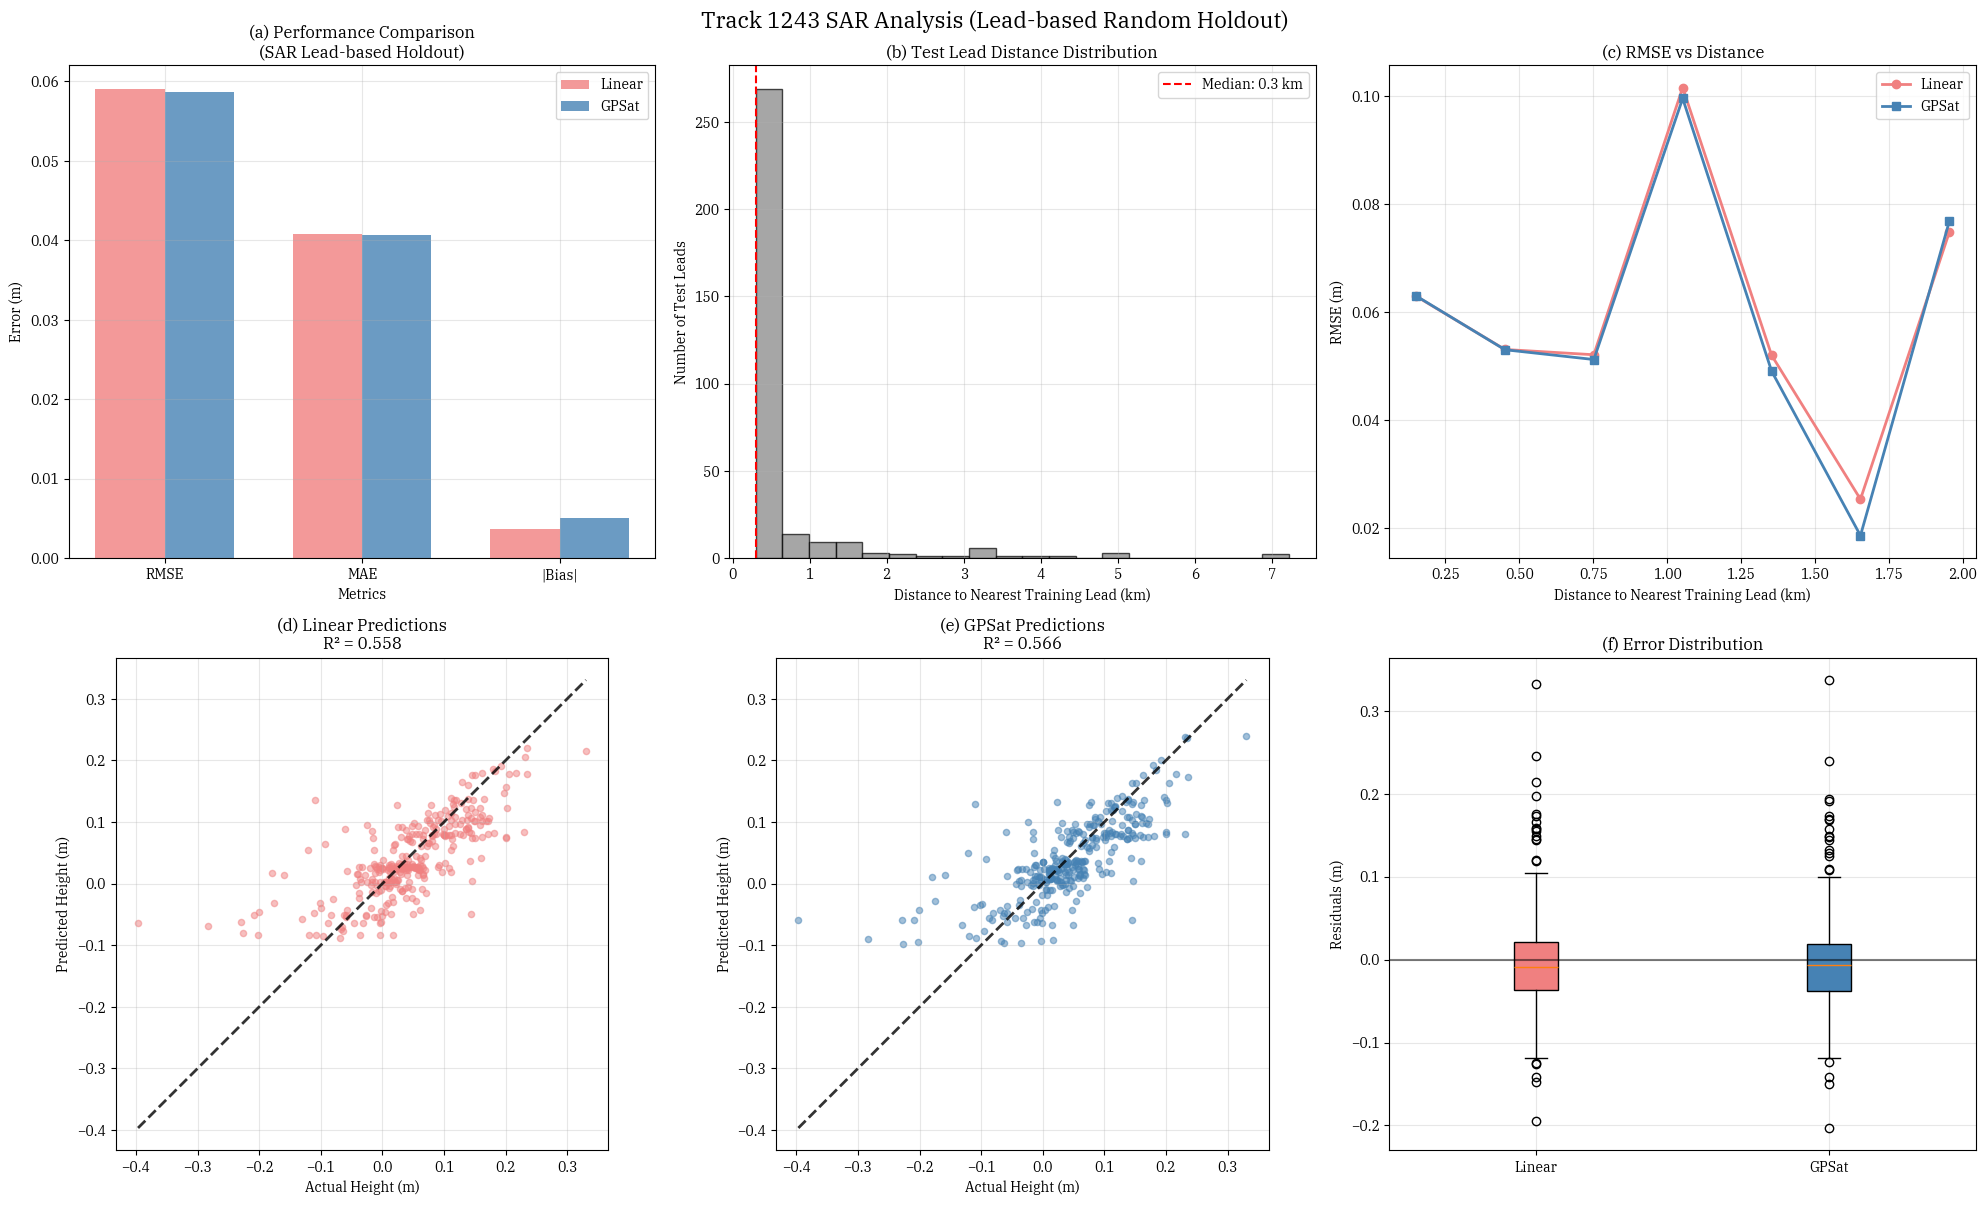

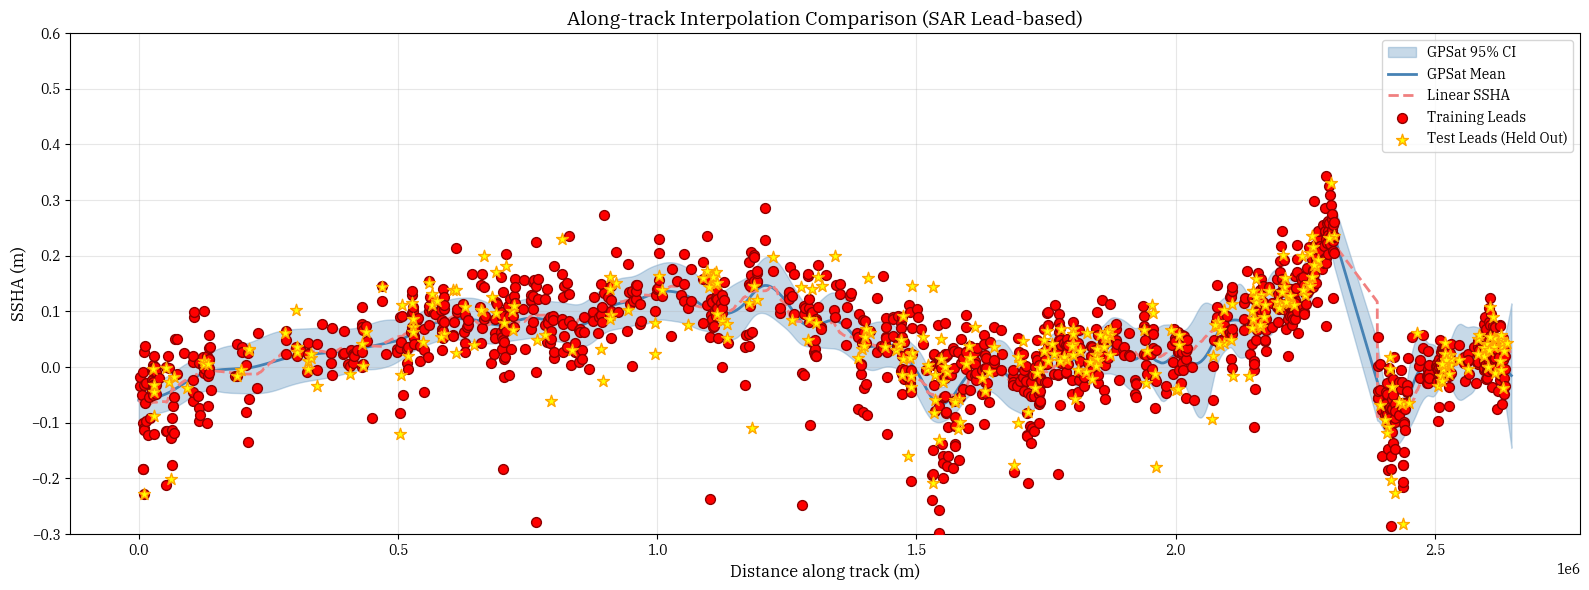

(along-track visualization)


In [94]:
create_single_lead_plot(plot_data_df, results_df, metrics_df, track=1243)

In [91]:
plot_data_df, results_df, metrics_df = random_holdout_test(downsized_df, gpsat_experts=128)

Interpolating track 1243, 1 of 5...


/tmp/ipykernel_1211405/832718476.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  track_df['train_mask'] = track_df.index.isin(train_lead_idx)


in json_serializable - key: 'source' has value DataFrame/Series, but is too long: 105 >  100
storing as str
'data_select': 0.000 seconds
'load': 0.000 seconds
in json_serializable - key: 'data_source' has value DataFrame/Series, but is too long: 1290 >  100
storing as str
in json_serializable - key: 'df' has value DataFrame/Series, but is too long: 5205 >  100
storing as str
---------
storing expert locations in 'expert_locs' table
exception occurred: 'No object named expert_locs in the file'
will now close object

---------
dropping expert locations that already exists in 'run_details' table
exception occurred: 'No object named run_details in the file'
will now close object

--------------------------------------------------
1 / 105
current local expert:
                     x              y        lon        lat        t  \
2573651 -584280.987782 -430861.767792 -53.594113  83.496633  18262.0   

                z  track date_string satellite  lead_mask  dist_along_track  \
2573651 -0

2026-05-20 20:50:25.342223: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /device:GPU:0 with 20872 MB memory:  -> device: 0, name: NVIDIA L4, pci bus id: 0000:42:00.0, compute capability: 8.9
2026-05-20 20:50:25.345893: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /device:GPU:1 with 20872 MB memory:  -> device: 1, name: NVIDIA L4, pci bus id: 0000:c4:00.0, compute capability: 8.9


**********
optimization failed!
'optimise_parameters': 0.696 seconds
'get_parameters': 0.006 seconds
parameters:
lengthscales: array([10.00997233, 10.00994317,  0.99822433]) 
kernel_variance: 0.0013667877537881785
likelihood_variance: 0.004187448605488844
'predict': 0.046 seconds
total run time : 1.93 seconds
--------------------------------------------------
2 / 105
current local expert:
                     x              y        lon        lat        t        z  \
2573685 -570418.599441 -411052.893457 -54.222867  83.701745  18262.0 -0.00557   

         track date_string satellite  lead_mask  dist_along_track  \
2573685   1243  2020-01-01       cs2        1.0      25551.212003   

         z_track_avg  train_mask  
2573685     0.040157        True  
'local_data_select': 0.001 seconds
number obs: 124
found GPU
setting lengthscales to: [1. 1. 1.]
'__init__': 0.090 seconds
'set_lengthscales_constraints': 0.017 seconds
'set_likelihood_variance_constraints': 0.020 seconds


...

2026-05-20 21:00:41.983559: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /device:GPU:0 with 20872 MB memory:  -> device: 0, name: NVIDIA L4, pci bus id: 0000:42:00.0, compute capability: 8.9
2026-05-20 21:00:41.985840: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /device:GPU:1 with 20872 MB memory:  -> device: 1, name: NVIDIA L4, pci bus id: 0000:c4:00.0, compute capability: 8.9


'get_parameters': 0.012 seconds
parameters:
lengthscales: array([12.        , 12.        ,  0.94299441]) 
kernel_variance: 0.018725229411397825
likelihood_variance: 0.01100000000000001
'predict': 0.050 seconds
total run time : 1.51 seconds
--------------------------------------------------
4 / 4
current local expert:
                    x              y        lon        lat        t         z  \
2580849 -1.105724e+06 -377896.257392 -71.131439  79.522468  18262.0 -0.087094   

         track date_string satellite  lead_mask  dist_along_track  \
2580849   1247  2020-01-01       cs2        1.0      74241.205037   

         z_track_avg  train_mask  
2580849    -0.185519        True  
'local_data_select': 0.001 seconds
number obs: 20
found GPU
setting lengthscales to: [1. 1. 1.]
'__init__': 0.090 seconds
'_read_params_from_file': 0.044 seconds
'set_parameters': 0.011 seconds
'set_lengthscales_constraints': 0.013 seconds
'set_likelihood_variance_constraints': 0.028 seconds
*** not optimisi

2026-05-20 21:00:43.501636: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /device:GPU:0 with 20872 MB memory:  -> device: 0, name: NVIDIA L4, pci bus id: 0000:42:00.0, compute capability: 8.9
2026-05-20 21:00:43.503142: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /device:GPU:1 with 20872 MB memory:  -> device: 1, name: NVIDIA L4, pci bus id: 0000:c4:00.0, compute capability: 8.9


'get_parameters': 0.007 seconds
parameters:
lengthscales: array([12.        , 12.        ,  0.94299441]) 
kernel_variance: 0.018725229411397825
likelihood_variance: 0.01100000000000001
'predict': 0.051 seconds
total run time : 1.53 seconds
storing any remaining tables
SAVING RESULTS TO TABLES:
run_details
preds
'run': 6.178 seconds
reading in results
getting all tables
merging on expert location data
table: 'oi_config' does not have all coords_col: ['x', 'y', 't'] in columns, not merging on expert_locations
table: 'oi_config_SMOOTHED' does not have all coords_col: ['x', 'y', 't'] in columns, not merging on expert_locations
Test NaNs — Linear: 0, GPSat: 0
Track interpolated!
All tracks interpolated


/tmp/ipykernel_1211405/832718476.py:221: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  track_df['f_gpsat'] = ssha
/tmp/ipykernel_1211405/832718476.py:222: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  track_df['f_var_gpsat'] = ssha_var
/tmp/ipykernel_1211405/832718476.py:223: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/use

In [10]:
dfs, _ = get_results_from_h5file('/home/mhen/geol0069_data/gpsat/jan20/1243.h5')

run_details = dfs['run_details']
run_details_SMOOTHED = dfs['run_details_SMOOTHED']

reading in results
getting all tables
merging on expert location data
table: 'oi_config' does not have all coords_col: ['x', 'y', 't'] in columns, not merging on expert_locations
table: 'oi_config_SMOOTHED' does not have all coords_col: ['x', 'y', 't'] in columns, not merging on expert_locations


In [12]:
run_details.head()

,x,y,t,_dim_0,num_obs,run_time,objective_value,parameters_optimised,optimise_success,model,...,config_id,lon,lat,z,track,date_string,satellite,lead_mask,dist_along_track,z_track_avg
0,-584280.987782,-430861.767792,18262.0,0,116,0.415894,-148.145213,True,False,GPSat.models.gpflow_models.GPflowGPRModel,...,1,-53.594113,83.496633,-0.034818,1243,2020-01-01,cs2,1.0,1502.990248,0.040157
1,-570418.599441,-411052.893457,18262.0,0,124,0.384719,-162.322020,True,True,GPSat.models.gpflow_models.GPflowGPRModel,...,1,-54.222867,83.701745,-0.005570,1243,2020-01-01,cs2,1.0,25551.212003,0.040157
2,-555327.315351,-389517.775035,18262.0,0,133,0.398521,-176.598838,True,True,GPSat.models.gpflow_models.GPflowGPRModel,...,1,-54.953406,83.923938,0.000517,1243,2020-01-01,cs2,1.0,51704.152824,0.040157
3,-542825.464630,-371701.254797,18262.0,0,136,0.363707,-177.445625,True,True,GPSat.models.gpflow_models.GPflowGPRModel,...,1,-55.598498,84.107068,0.049702,1243,2020-01-01,cs2,1.0,73348.337332,0.040157
4,-525095.068321,-346469.863559,18262.0,0,139,0.372275,-182.751731,True,True,GPSat.models.gpflow_models.GPflowGPRModel,...,1,-56.582249,84.365197,-0.061733,1243,2020-01-01,cs2,1.0,104011.745256,0.040157


In [15]:
run_time = run_details['run_time']
run_time_SMOOTHED = run_details_SMOOTHED['run_time']

total_time = run_time.cumsum()
total_time_SMOOTHED = run_time_SMOOTHED.cumsum()

total_interp_time = total_time.iloc[-1] + total_time_SMOOTHED.iloc[-1]

print(total_interp_time)

27.088502883911133


In [11]:
print(dfs.keys())

dict_keys(['expert_locs', 'expert_locs_SMOOTHED', 'kernel_variance', 'kernel_variance_SMOOTHED', 'lengthscales', 'lengthscales_SMOOTHED', 'likelihood_variance', 'likelihood_variance_SMOOTHED', 'oi_config', 'oi_config_SMOOTHED', 'preds', 'preds_SMOOTHED', 'run_details', 'run_details_SMOOTHED'])


In [12]:
preds = dfs['preds']
preds_SMOOTHED = dfs['preds_SMOOTHED']

In [15]:
print(preds)

                   x              y        t  _dim_0        f*    f*_var  \
0     -584280.987782 -430861.767792  18262.0       0 -0.065764  0.000185   
1     -584280.987782 -430861.767792  18262.0       1 -0.065842  0.000174   
2     -584280.987782 -430861.767792  18262.0       2 -0.065852  0.000172   
3     -584280.987782 -430861.767792  18262.0       3 -0.065861  0.000170   
4     -584280.987782 -430861.767792  18262.0       4 -0.065874  0.000166   
...              ...            ...      ...     ...       ...       ...   
62760  -16901.524477  359202.028419  18262.0    1726  0.093146  0.000713   
62761  -16901.524477  359202.028419  18262.0    1727  0.092828  0.000731   
62762  -16901.524477  359202.028419  18262.0    1728  0.092668  0.000740   
62763  -16901.524477  359202.028419  18262.0    1729  0.092507  0.000749   
62764  -16901.524477  359202.028419  18262.0    1730  0.092345  0.000759   

          y_var  f_bar     pred_loc_x     pred_loc_y  pred_loc_t         lon  \
0      